In [63]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

2.13.0
False
No GPU found


In [64]:
import torch
print(torch.version.cuda)


None


SPLIT DATASET 

Load requirement 

In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from PIL import Image

In [66]:
print("PyTorch version:", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

PyTorch version: 2.13.0
Using device: mps


In [67]:
for root, dirs, files in os.walk("data"):
    print(root, "->", len(files), "files")

In [68]:
import os

print(os.getcwd())
print(os.listdir("."))

/Users/krish/data-science/week05-deep-learning/day-6
['catsdogs_extracted', 'kagglecatsanddogs_5340.zip', 'week05_day6.ipynb', 'Screenshot 2026-08-11 at 2.54.40\u202fPM.png', 'mini_DL_classification.ipynb']


Unzip the file 

In [69]:
import zipfile

zip_path = "kagglecatsanddogs_5340.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files = zip_ref.namelist()

print("Number of files:", len(files))

print("\nFirst 30 files:")
for file in files[:30]:
    print(file)

Number of files: 25006

First 30 files:
PetImages/Cat/
PetImages/Cat/0.jpg
PetImages/Cat/1.jpg
PetImages/Cat/10.jpg
PetImages/Cat/100.jpg
PetImages/Cat/1000.jpg
PetImages/Cat/10000.jpg
PetImages/Cat/10001.jpg
PetImages/Cat/10002.jpg
PetImages/Cat/10003.jpg
PetImages/Cat/10004.jpg
PetImages/Cat/10005.jpg
PetImages/Cat/10006.jpg
PetImages/Cat/10007.jpg
PetImages/Cat/10008.jpg
PetImages/Cat/10009.jpg
PetImages/Cat/1001.jpg
PetImages/Cat/10010.jpg
PetImages/Cat/10011.jpg
PetImages/Cat/10012.jpg
PetImages/Cat/10013.jpg
PetImages/Cat/10014.jpg
PetImages/Cat/10015.jpg
PetImages/Cat/10016.jpg
PetImages/Cat/10017.jpg
PetImages/Cat/10018.jpg
PetImages/Cat/10019.jpg
PetImages/Cat/1002.jpg
PetImages/Cat/10020.jpg
PetImages/Cat/10021.jpg


Extraction

In [70]:
import os
import zipfile

zip_path = "kagglecatsanddogs_5340.zip"
extract_path = "catsdogs_extracted"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [71]:
print(os.listdir("catsdogs_extracted"))

['PetImages', 'readme[1].txt', 'CDLA-Permissive-2.0.pdf']


In [72]:
print(os.listdir("catsdogs_extracted/PetImages"))

['Cat', 'Dog']


Check of the size of the dataset 

In [73]:
cat_path = "catsdogs_extracted/PetImages/Cat"
dog_path = "catsdogs_extracted/PetImages/Dog"

cat_images = [
    f for f in os.listdir(cat_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

dog_images = [
    f for f in os.listdir(dog_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Cat images:", len(cat_images))
print("Dog images:", len(dog_images))

Cat images: 12500
Dog images: 12500


In [74]:
from torchvision import datasets, transforms

In [75]:
dataset_path = "catsdogs_extracted/PetImages"

dataset = datasets.ImageFolder(
    root=dataset_path
)

In [76]:
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Total images:", len(dataset))

Classes: ['Cat', 'Dog']
Class mapping: {'Cat': 0, 'Dog': 1}
Total images: 25000


Import the dataset 

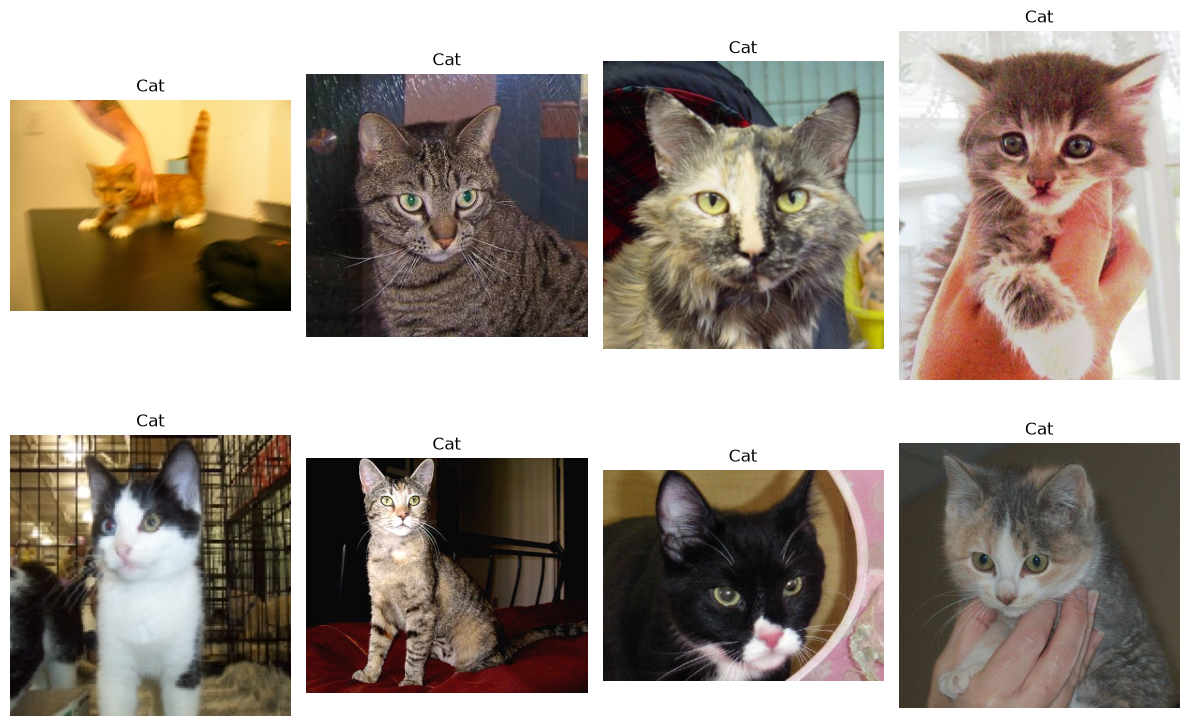

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(8):

    image, label = dataset[i]

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(dataset.classes[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

check for bad image 

In [78]:
from PIL import Image
import os

bad_images = []

for class_name in ["Cat", "Dog"]:

    folder = os.path.join(
        dataset_path,
        class_name
    )

    for filename in os.listdir(folder):

        filepath = os.path.join(
            folder,
            filename
        )

        try:
            with Image.open(filepath) as img:
                img.verify()

        except Exception:
            bad_images.append(filepath)

print("Bad images:", len(bad_images))

if bad_images:
    print("\nExamples:")
    for image in bad_images[:10]:
        print(image)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Bad images: 4

Examples:
catsdogs_extracted/PetImages/Cat/Thumbs.db
catsdogs_extracted/PetImages/Cat/666.jpg
catsdogs_extracted/PetImages/Dog/Thumbs.db
catsdogs_extracted/PetImages/Dog/11702.jpg


In [79]:
for image in bad_images:
    os.remove(image)

print(f"Removed {len(bad_images)} bad images.")

Removed 4 bad images.


Create train test split

In [80]:
from sklearn.model_selection import train_test_split
import numpy as np

In [81]:
indices = np.arange(len(dataset))
labels = np.array(dataset.targets)

In [82]:
train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

In [83]:
temp_labels = labels[temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

size of the split 

In [84]:
print("Training:", len(train_indices))
print("Validation:", len(val_indices))
print("Testing:", len(test_indices))

Training: 17500
Validation: 3750
Testing: 3750


Create transformation 

In [85]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [86]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Dataset with different transformation 


In [87]:
train_full = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

test_full = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

In [88]:
from torch.utils.data import Subset

train_dataset = Subset(
    train_full,
    train_indices
)

val_dataset = Subset(
    test_full,
    val_indices
)

test_dataset = Subset(
    test_full,
    test_indices
)

Create dataloaders 

In [89]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

Verify one batch 

In [90]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## At this point your dataset is successfully imported, split, transformed, and loaded into PyTorch.

Load pretrained ResNet18

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torchvision.models import ResNet18_Weights

In [92]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


Load 

In [93]:
weights = ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

print("ResNet18 loaded successfully!")

ResNet18 loaded successfully!


freeze the pretrained layer 

In [94]:
for param in model.parameters():
    param.requires_grad = False

In [95]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11689512
Trainable parameters: 0


replace the final layer 

In [96]:
num_classes = 2

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

In [97]:
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


Make new layer trainable 

In [98]:
print(
    "FC layer trainable:",
    model.fc.weight.requires_grad
)

FC layer trainable: True


In [99]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)

Trainable parameters: 1026


move model to machine 

In [100]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: mps


Define loss function

In [101]:
criterion = nn.CrossEntropyLoss()

In [102]:
criterion = nn.CrossEntropyLoss()

Optimizer

In [103]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [104]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Check one batch before training 

In [105]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [106]:
images = images.to(device)
labels = labels.to(device)

In [107]:
outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 2])


Underrstand the output

In [108]:
print(outputs[0])

tensor([-0.0246,  0.1160], device='mps:0', grad_fn=<SelectBackward0>)


In [109]:
probabilities = torch.softmax(
    outputs,
    dim=1
)

print(probabilities[0])

tensor([0.4649, 0.5351], device='mps:0', grad_fn=<SelectBackward0>)


In [110]:
print(dataset.class_to_idx)

{'Cat': 0, 'Dog': 1}


Creation of the training function

In [111]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        # Predictions
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Validation function 

In [112]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            predictions = outputs.argmax(
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Train resNest18 

In [116]:
from torchvision import datasets

dataset_path = "catsdogs_extracted/PetImages"

dataset = datasets.ImageFolder(
    root=dataset_path
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['Cat', 'Dog']
Total images: 24998


In [117]:
import numpy as np
from sklearn.model_selection import train_test_split

indices = np.arange(len(dataset))
labels = np.array(dataset.targets)

train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=42,
    stratify=labels[temp_indices]
)

print("Training:", len(train_indices))
print("Validation:", len(val_indices))
print("Testing:", len(test_indices))

Training: 17498
Validation: 3750
Testing: 3750


recreate the transform from here every thing is recreated 

In [118]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_full = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

test_full = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

In [119]:
from torch.utils.data import Subset

train_dataset = Subset(
    train_full,
    train_indices
)

val_dataset = Subset(
    test_full,
    val_indices
)

test_dataset = Subset(
    test_full,
    test_indices
)

In [120]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [121]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [122]:
images, labels = next(iter(val_loader))

print("Validation images:", images.shape)
print("Validation labels:", labels.shape)

Validation images: torch.Size([32, 3, 224, 224])
Validation labels: torch.Size([32])


In [123]:
images, labels = next(iter(test_loader))

print("Test images:", images.shape)
print("Test labels:", labels.shape)

Test images: torch.Size([32, 3, 224, 224])
Test labels: torch.Size([32])


In [124]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [125]:
weights = ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

In [126]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)

Input: torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 2])


In [127]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

UPDATED FOM HERE 

In [128]:
num_epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    # =========================
    # SAVE RESULTS
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/5] | Train Loss: 0.1382 | Train Acc: 0.9486 | Val Loss: 0.0789 | Val Acc: 0.9683
Epoch [2/5] | Train Loss: 0.0923 | Train Acc: 0.9628 | Val Loss: 0.0629 | Val Acc: 0.9752
Epoch [3/5] | Train Loss: 0.0831 | Train Acc: 0.9681 | Val Loss: 0.0647 | Val Acc: 0.9741
Epoch [4/5] | Train Loss: 0.0877 | Train Acc: 0.9653 | Val Loss: 0.0600 | Val Acc: 0.9771
Epoch [5/5] | Train Loss: 0.0869 | Train Acc: 0.9647 | Val Loss: 0.0605 | Val Acc: 0.9749


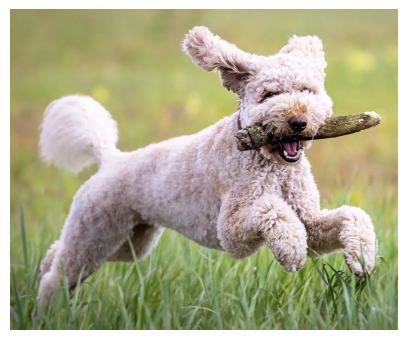

In [129]:
from PIL import Image

image_path = "/Users/krish/data-science/week05-deep-learning/day-6/eg1.png"

image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(5, 5))

plt.imshow(image)
plt.axis("off")

plt.show()

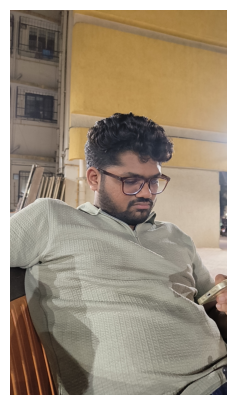

In [130]:
from PIL import Image

image_path = "/Users/krish/data-science/week05-deep-learning/day-6/eg2.jpeg"

image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(5, 5))

plt.imshow(image)
plt.axis("off")

plt.show()

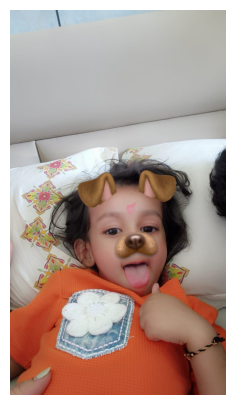

In [131]:
from PIL import Image

image_path = "/Users/krish/data-science/week05-deep-learning/day-6/eg5.jpeg"

image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(5, 5))

plt.imshow(image)
plt.axis("off")

plt.show()

In [132]:
image_tensor = test_transform(image)

In [133]:
image_tensor = image_tensor.unsqueeze(0)

In [134]:
print(image_tensor.shape)

torch.Size([1, 3, 224, 224])


In [135]:
image_tensor = image_tensor.to(device)

model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    prediction = output.argmax(
        dim=1
    ).item()

In [136]:
print(dataset.class_to_idx)

{'Cat': 0, 'Dog': 1}


In [137]:
classes = dataset.classes

predicted_class = classes[prediction]

confidence = probabilities[
    0,
    prediction
].item()

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2%}")

Prediction: Cat
Confidence: 86.86%


In [138]:
print(
    f"Cat probability: {probabilities[0][0].item():.2%}"
)

print(
    f"Dog probability: {probabilities[0][1].item():.2%}"
)

Cat probability: 86.86%
Dog probability: 13.14%


In [140]:
def predict_image(image_path, model, transform, device, classes):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = output.argmax(
            dim=1
        ).item()

    predicted_class = classes[prediction]

    confidence = probabilities[
        0,
        prediction
    ].item()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"{predicted_class} ({confidence:.2%})"
    )
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

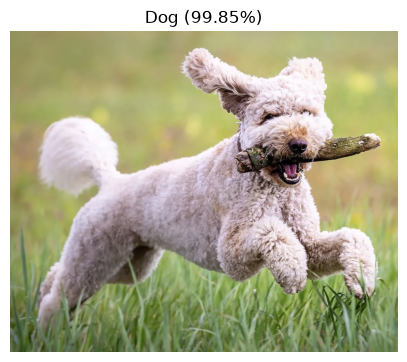

('Dog', 0.9984806180000305)

In [141]:
predict_image(
    "/Users/krish/data-science/week05-deep-learning/day-6/eg1.png",
    model,
    test_transform,
    device,
    dataset.classes
)

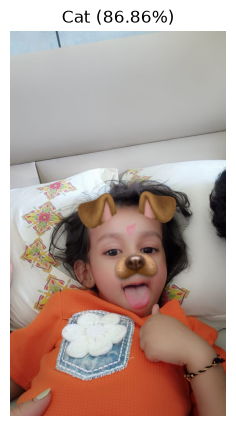

('Cat', 0.8686426281929016)

In [142]:
predict_image(
    "/Users/krish/data-science/week05-deep-learning/day-6/eg5.jpeg",
    model,
    test_transform,
    device,
    dataset.classes
)

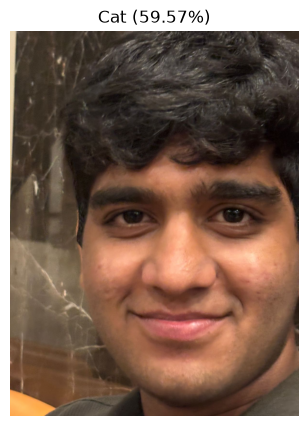

('Cat', 0.5956865549087524)

In [144]:
predict_image(
    "/Users/krish/data-science/week05-deep-learning/day-6/eg3.jpeg",
    model,
    test_transform,
    device,
    dataset.classes
    
)

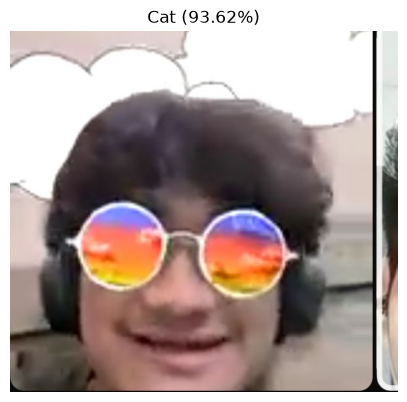

('Cat', 0.9361947178840637)

In [145]:
predict_image(
    "/Users/krish/data-science/week05-deep-learning/day-6/eg4.jpeg",
    model,
    test_transform,
    device,
    dataset.classes
)

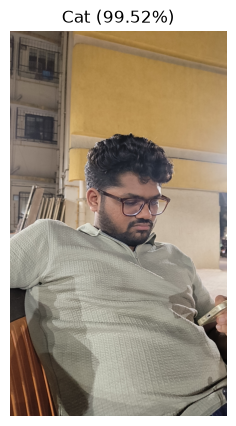

('Cat', 0.9952495098114014)

In [146]:
predict_image(
    "/Users/krish/data-science/week05-deep-learning/day-6/eg2.jpeg",
    model,
    test_transform,
    device,
    dataset.classes
)

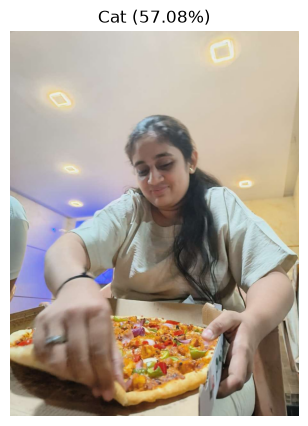

('Cat', 0.5708207488059998)

In [148]:
predict_image(
    "/Users/krish/data-science/week05-deep-learning/day-6/eg6.jpg",
    model,
    test_transform,
    device,
    dataset.classes
)